<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Backpropagation: Fully-Connected Neural Nets

In the previous excercises you implemented a fully-connected two-layer neural network on CIFAR-10 based on image features. 

The implementation was not very modular since the loss and gradient were computed in a single monolithic function.

This is manageable for a simple two-layer network, but would become impractical as we move to bigger models. In other words the monolithic implementation does not scale. 

Ideally we want to build networks using a fully modular design so that we can implement different layer types in isolation and then snap them together into models with different architectures.

The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Nico
- LastName: Weber
- MatriculationNumber: 86071
----------

In this exercise we will implement fully-connected networks using a modular approach. For each layer we will implement a `forward` and a `backward` function. The `forward` function will receive inputs, weights, and other parameters and will return both an output and a `cache` object storing data needed for the backward pass, like this:

```python
def layer_forward(x, w):
  """ Receive inputs x and weights w """
  # Do some computations ...
  z = # ... some intermediate value
  # Do some more computations ...
  out = # the output
   
  cache = (x, w, z, out) # Values we need to compute gradients
   
  return out, cache
```

The backward pass will receive upstream derivatives and the `cache` object, and will return gradients with respect to the inputs and weights, like this:

```python
def layer_backward(dout, cache):
  """
  Receive dout (derivative of loss with respect to outputs) and cache,
  and compute derivative with respect to inputs.
  """
  # Unpack cache values
  x, w, z, out = cache
  
  # Use values in cache to compute derivatives
  dx = # Derivative of loss with respect to x
  dw = # Derivative of loss with respect to w
  
  return dx, dw
```

After implementing a bunch of layers this way, we will be able to easily combine them to build classifiers with different architectures.

In addition to implementing fully-connected networks of arbitrary depth, we will also explore different update rules for optimization, and introduce Dropout as a regularizer and Batch/Layer Normalization as a tool to more efficiently optimize deep networks.
  

In [1]:
cifar10_dir = '../datasets/cifar-10-batches-py'

import os.path

# Get the CIFAR10 data if not present
if os.path.isdir(cifar10_dir):
    print ("CIFAR10 folder exist, skipping download. If you encouter errors, load and unpack the data manually.")
else:
    !mkdir ../datasets/
    !cd ../datasets/ && wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O cifar-10-python.tar.gz && tar -xzvf cifar-10-python.tar.gz && rm cifar-10-python.tar.gz 

Syntaxfehler.
Das System kann den angegebenen Pfad nicht finden.


In [2]:
# As usual, a bit of setup
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from EITB712M.classifiers.fc_net import *
from EITB712M.data_utils import get_CIFAR10_data
from EITB712M.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from EITB712M.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

=========== You can safely ignore the message below if you are NOT working on ConvolutionalNetworks.ipynb ===========
	You will need to compile a Cython extension for a portion of this assignment.
	The instructions to do this will be given in a section of the notebook below.


In [3]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# Affine layer (=fully-connected): forward

-----------
<span style="color:blue">**Open the file `EITB712M/layers.py` and implement the `affine_forward` function. Remember the fully connected layer is using the function:**</span>

$f(x,W,b)=z=xW + b$ the result is of type $[NxM]$.

Note: In the previous discussions we denoted size of this layer as $[NxC]$ (with respect to the classes) or $[NxH]$ (with respect to the hidden neurons). As we want to become modular and therefore don't know the output size (as it depends on the size of the weights $[DxM]$ for $W$, $[M]$ for $b$ and inputs $[NxD]$), we use $M$ to help us to remember that our implementation can potentially be used as a layer anywhere in our neuronal network.

Hint: This should be straigtforward to implement. Nevertheless you should keep an eye on the shapes. We'll call the result of the function 'out'. 
    
<span style="color:blue">**Once you are done test your implementaion by running the following:**</span>

In [4]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


# Affine layer (=fully-connected): backward

-----------
<span style="color:blue">**Now implement the `affine_backward` function and test your implementation using numeric gradient checking.**</span>

Remember the local-gradients of the function $f(x,W,b)=z=W x + b$ with respect to W, x, b are:

$\frac{\partial z}{\partial W}=x$

$\frac{\partial z}{\partial x}=W$

$\frac{\partial z}{\partial b}=1$ 'Einsmatrix'

To get the gradients $\frac{\partial L}{\partial W}$ ('dw'), $\frac{\partial L}{\partial x}$ ('dx') and $\frac{\partial L}{\partial b}$ ('db') in respect to the upstream gradient $\frac{\partial L}{\partial z}$ ('dout') you need to compute the dot-product of the upstream gradient with your local gradients: 

$\frac{\partial L}{\partial W}=\frac{\partial L}{\partial z}\frac{\partial z}{\partial W}=X^T \cdot \frac{\partial L}{\partial z}$ the result is of type $[DxM]$ (same as $W$).

$\frac{\partial L}{\partial x}=\frac{\partial L}{\partial z}\frac{\partial z}{\partial x}=\frac{\partial L}{\partial z} \cdot W^T$ the result is of type $[NxD]$ (same as $x$).

$\frac{\partial L}{\partial b}=\frac{\partial L}{\partial z}\frac{\partial z}{\partial b}=\sum_{N} \frac{\partial L}{\partial z}$ the result is of type $[M]$ (same as $b$).

Hint: The upstream gradient needs to be of size $[NxM]$ (same as $z$).

In [5]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


# ReLU activation: forward

<span style="color:blue">**Implement the forward pass for the ReLU activation function in the `relu_forward` function.**</span>

$f(x)=z=max(0,x)$ <br>
(same size as $x$).

Hint: This should be straigtforward to implement. Nevertheless you should keep an eye on the shapes. We'll call the result of the function 'out'. 
    
<span style="color:blue">**Once you are done test your implementaion by running the following:**</span>

In [6]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


# ReLU activation: backward

Now implement the backward pass for the ReLU activation function in the `relu_backward` function and test your implementation using numeric gradient checking:

-----------
<span style="color:blue">**Now implement the backward pass for the ReLU activation function and test your implementation using numeric gradient checking.**</span>

Remember the local-gradient of the function $f(x)=z=max(0,x)$ with respect to x is:

$\frac{\partial z}{\partial x}=\unicode{x1D7D9}(x > 0)$

To get the gradient $\frac{\partial L}{\partial x}$ ('dx') in respect to the upstream gradient $\frac{\partial L}{\partial z}$ ('dout') you need to compute the dot-product of the upstream gradient with your local gradient: 

$\frac{\partial L}{\partial x}=\frac{\partial L}{\partial z}\frac{\partial z}{\partial x}$

In the lecture we discussed the backpropagation patter for the max-function as a "switch" for the gradient flow. The gradient flows into the direction of the highest input. Therefore the gradient can be calculated using the Hadamard product: 

$\frac{\partial L}{\partial x}=\frac{\partial L}{\partial z} \circ \unicode{x1D7D9}(x > 0)$

In [7]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


## Inline Question 1: 

We've only asked you to implement ReLU, but there are a number of different activation functions that one could use in neural networks, each with its pros and cons. In particular, an issue commonly seen with activation functions is getting zero (or close to zero) gradient flow during backpropagation. Which of the following activation functions have this problem? If you consider these functions in the one dimensional case, what types of input would lead to this behaviour?
1. Sigmoid
2. ReLU
3. Leaky ReLU

$\color{blue}{\textit Your Answer:}$

> Sigmoid und ReLU nehmen bei keiner Aktivierung sehr geringe Werte für den lokalen Gradienten an. Leaky ReLU verringert das Problem des verschwindenden Gradienten, indem ein positiver Gradient bei Nichtaktivierung erhalten bleibt.

$\color{blue}{\textit Your Explanation:}$

> siehe oben



# "Sandwich" layers
There are some common patterns of layers that are frequently used in neural nets. For example, affine layers are frequently followed by a ReLU nonlinearity. To make these common patterns easy, we define several convenience layers in the file `EITB712M/layer_utils.py`.

<span style="color:blue">**For now take a look at the `affine_relu_forward` and `affine_relu_backward` functions, and run the following to numerically gradient check the backward pass:**</span>

In [8]:
from EITB712M.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


# Loss layers: Softmax and MSVM

You implemented the MSVM loss function in the last assignment, so we'll give them (Softmax and MSVM) to you for free here. 

<span style="color:blue">**You should still make sure you understand how they work by looking at the implementations in `EITB712M/layers.py`.**</span>

You can make sure that the implementations are correct by running the following:

In [9]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)

dx_num = eval_numerical_gradient(lambda x: svm_loss(x, y)[0], x, verbose=False)
loss, dx = svm_loss(x, y)

# Test svm_loss function. Loss should be around 9 and dx error should be around the order of e-9
print('Testing svm_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

Testing svm_loss:
loss:  8.999602749096233
dx error:  1.4021566006651672e-09

Testing softmax_loss:
loss:  2.302545844500738
dx error:  9.384673161989355e-09


# Two-layer network

In the previous ercercise you implemented a two-layer neural network in a single monolithic class. Now that you have implemented modular versions of the necessary layers, you will reimplement the two layer network using these modular implementations.

<span style="color:blue">**Open the file `EITB712M/classifiers/fc_net.py` and complete the implementation of the `TwoLayerNet` class. This time use the softmax classifier from `EITB712M/classifiers/layers.py` instead.**</span> 

The score-function is still:
$f=W_2 max(0,W_1 x + b_1)+b_2$

Hint: Use the functions 'affine_relu_forward' & 'affine_forward' to caclulate the forward-path and 'affine_backward' & 'affine_relu_backward' to calculate the backward-path. The function 'softmax_loss' gives you the possibility to calculate the loss. 

This class will serve as a model for the other networks you will implement in this excercise, so read through it to make sure you understand the API. You can run the cell below to test your implementation.

In [12]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.12e-10
b1 relative error: 9.83e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 7.76e-10


# Solver

In the previous excercise, the logic for training models was coupled to the models themselves. 
Following a more modular design, for this excercise we have split  the logic for training models into a separate class.

<span style="color:blue">**Open the file `EITB712M/solver.py` and read through it to familiarize yourself with the API. After doing so, use a `Solver` instance to train a `TwoLayerNet` that achieves at least `50%` accuracy on the validation set.**</span>

In [14]:
# The cell runs about 1 hour (depending on your computing power)

model = TwoLayerNet()
solver = None
best_val = -1

# Generate random hyperparameters given ranges for each of them
def generate_random_hyperparams(lr_min, lr_max, reg_min, reg_max, h_min, h_max):
    lr = 10**np.random.uniform(lr_min,lr_max)
    reg = 10**np.random.uniform(reg_min,reg_max)
    hidden = np.random.randint(h_min, h_max)
    return lr, reg, hidden

for i in range(40):
                         # generate_random_hyperparams(lr_min, lr_max, reg_min, reg_max, h_min, h_max)
    lr, reg, hidden_size = generate_random_hyperparams(    -4,     -1,      -7,      -3,    75,   500)
    model = TwoLayerNet(hidden_dim = hidden_size, reg= reg)
    
    ##############################################################################
    # TODO: Use a Solver instance to train a TwoLayerNet that achieves at least  #
    # 50% accuracy on the validation set.                                        #
    ##############################################################################
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
    cur_solver = Solver(
        model, 
        data, 
        # KORREKTUR: Verwende 'lr' direkt statt max(lr, 1e-3)
        # Dies war der Grund für die NaN-Fehler in deiner Ausgabe.
        optim_config={'learning_rate': lr},
        lr_decay=0.95,                                 
    ) 
    cur_solver.train()
    
    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################
    
    val_accuracy = cur_solver.best_val_acc
    if best_val < val_accuracy:
        best_val = val_accuracy
        solver = cur_solver
    # Print results
    print('lr %e reg %e hid %d  val accuracy: %f' % (
                lr, reg, hidden_size, val_accuracy))
print('best validation accuracy achieved: %f' % best_val)

(Iteration 1 / 4900) loss: 2.302352
(Epoch 0 / 10) train acc: 0.214000; val_acc: 0.195000
(Iteration 11 / 4900) loss: 402446853.629805
(Iteration 21 / 4900) loss: 2626996188586233561088.000000
(Iteration 31 / 4900) loss: 1256657809293577604138830340816896.000000
(Iteration 41 / 4900) loss: 119678092385977166479740228061711329029783552.000000
(Iteration 51 / 4900) loss: 57551270017033828871450881319494413494883574685787750400.000000
(Iteration 61 / 4900) loss: 4085799927021156694233413354098270077639853656088605296828503556096.000000
(Iteration 71 / 4900) loss: 11526795030575323495139581659445928145092651049063133790725665916640577156284416.000000
(Iteration 81 / 4900) loss: 2739217710269282988566213440949636722250053859850005800016582281120192821785224499276283904.000000
(Iteration 91 / 4900) loss: 1840057549248772539747429580357588930057173422100323334516852199649013188820142711518501056719720808448.000000
(Iteration 101 / 4900) loss: 11182826299088097097216981317136254113635655195071

c:\Users\nicog\OneDrive\Desktop\Arbeit\Hochschule\Neuronale-Netze\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\nicog\OneDrive\Desktop\Arbeit\Hochschule\Neuronale-Netze\EITB712M\layers.py:27: RuntimeWarning: overflow encountered in dot
  out = X.dot(w) + b
c:\Users\nicog\OneDrive\Desktop\Arbeit\Hochschule\Neuronale-Netze\EITB712M\layers.py:365: RuntimeWarning: overflow encountered in subtract
  shifted_logits = x - np.max(x, axis=1, keepdims=True)
c:\Users\nicog\OneDrive\Desktop\Arbeit\Hochschule\Neuronale-Netze\EITB712M\layers.py:365: RuntimeWarning: invalid value encountered in subtract
  shifted_logits = x - np.max(x, axis=1, keepdims=True)


(Iteration 291 / 4900) loss: nan
(Iteration 301 / 4900) loss: nan
(Iteration 311 / 4900) loss: nan
(Iteration 321 / 4900) loss: nan
(Iteration 331 / 4900) loss: nan
(Iteration 341 / 4900) loss: nan
(Iteration 351 / 4900) loss: nan
(Iteration 361 / 4900) loss: nan
(Iteration 371 / 4900) loss: nan
(Iteration 381 / 4900) loss: nan
(Iteration 391 / 4900) loss: nan
(Iteration 401 / 4900) loss: nan
(Iteration 411 / 4900) loss: nan
(Iteration 421 / 4900) loss: nan
(Iteration 431 / 4900) loss: nan
(Iteration 441 / 4900) loss: nan
(Iteration 451 / 4900) loss: nan
(Iteration 461 / 4900) loss: nan
(Iteration 471 / 4900) loss: nan
(Iteration 481 / 4900) loss: nan
(Epoch 1 / 10) train acc: 0.091000; val_acc: 0.087000
(Iteration 491 / 4900) loss: nan
(Iteration 501 / 4900) loss: nan
(Iteration 511 / 4900) loss: nan
(Iteration 521 / 4900) loss: nan
(Iteration 531 / 4900) loss: nan
(Iteration 541 / 4900) loss: nan
(Iteration 551 / 4900) loss: nan
(Iteration 561 / 4900) loss: nan
(Iteration 571 / 4900)

c:\Users\nicog\OneDrive\Desktop\Arbeit\Hochschule\Neuronale-Netze\EITB712M\classifiers\fc_net.py:100: RuntimeWarning: overflow encountered in multiply
  loss, grads = 0, {}


(Iteration 121 / 4900) loss: nan
(Iteration 131 / 4900) loss: nan
(Iteration 141 / 4900) loss: nan
(Iteration 151 / 4900) loss: nan
(Iteration 161 / 4900) loss: nan
(Iteration 171 / 4900) loss: nan
(Iteration 181 / 4900) loss: nan
(Iteration 191 / 4900) loss: nan
(Iteration 201 / 4900) loss: nan
(Iteration 211 / 4900) loss: nan
(Iteration 221 / 4900) loss: nan
(Iteration 231 / 4900) loss: nan
(Iteration 241 / 4900) loss: nan
(Iteration 251 / 4900) loss: nan
(Iteration 261 / 4900) loss: nan
(Iteration 271 / 4900) loss: nan
(Iteration 281 / 4900) loss: nan
(Iteration 291 / 4900) loss: nan
(Iteration 301 / 4900) loss: nan
(Iteration 311 / 4900) loss: nan
(Iteration 321 / 4900) loss: nan
(Iteration 331 / 4900) loss: nan
(Iteration 341 / 4900) loss: nan
(Iteration 351 / 4900) loss: nan
(Iteration 361 / 4900) loss: nan
(Iteration 371 / 4900) loss: nan
(Iteration 381 / 4900) loss: nan
(Iteration 391 / 4900) loss: nan
(Iteration 401 / 4900) loss: nan
(Iteration 411 / 4900) loss: nan
(Iteration

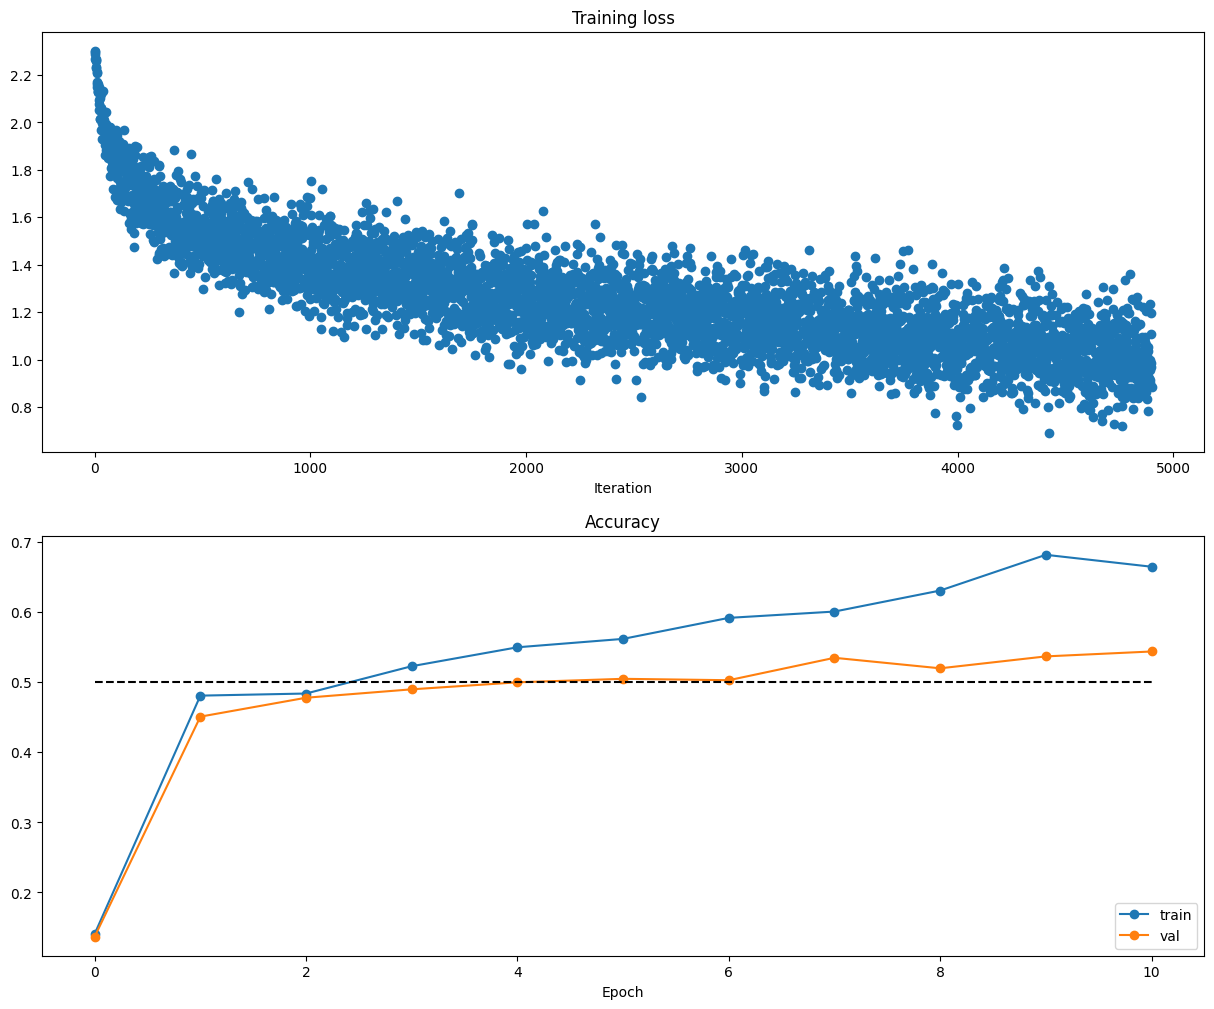

In [15]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()